<a href="https://colab.research.google.com/github/sangitag487-star/Artificial-Neural-Network/blob/main/ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
class MP_OR:
    def __init__(self):
        self.theta=1
    def predict(self,x1,x2):
        g=x1+x2
        if g>=self.theta:
            return 1
        else:
            return 0

In [3]:
orfun=MP_OR()
print(orfun.predict(1,1))

1


In [4]:
orfun=MP_OR()
print(orfun.predict(0,0))

0


In [5]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
#import cv2
import matplotlib.pyplot as plt

In [6]:
fashion=keras.datasets.fashion_mnist
(x_train,y_train),(x_test,y_test)=fashion.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
x_train.shape

(60000, 28, 28)

In [8]:
x_test.shape

(10000, 28, 28)

In [9]:
x_train,x_val=x_train[:10000]/255.0,x_train[10000:]/255.0
y_train,y_val=y_train[:10000],y_train[10000:]

In [10]:
y_train[3]

np.uint8(3)

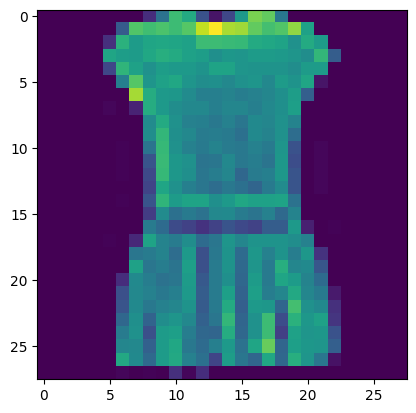

In [11]:
plt.imshow(x_train[3])

In [12]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat","Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [13]:

class_names[y_train[3]]


'Dress'

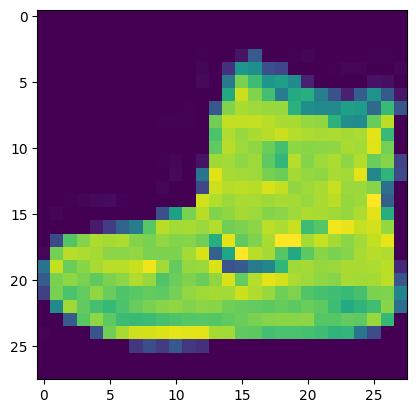

In [14]:
plt.imshow(x_train[0])

Dress


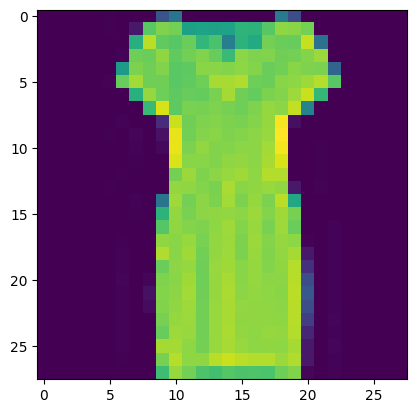

In [15]:
print(class_names[y_train[20]])
plt.imshow(x_train[20])

In [16]:
model=keras.models.Sequential()

In [17]:
model.add(keras.layers.Flatten(input_shape=[28,28]))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [18]:
model.add(keras.layers.Dense(300, activation="relu"))

In [19]:
model.add(keras.layers.Dense(100, activation="relu"))

In [20]:
model.add(keras.layers.Dense(10,activation='softmax'))

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.layers

[<Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dense name=dense_1, built=True>,
 <Dense name=dense_2, built=True>]

In [23]:
model.layers[0]

<Flatten name=flatten, built=True>

In [24]:

model.layers[1].name

'dense'

In [25]:
weights,bias=model.layers[1].get_weights()

In [26]:

weights.shape

(784, 300)

In [27]:
bias.shape

(300,)

In [28]:
weights,bias=model.layers[2].get_weights()

In [29]:

bias

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
      dtype=float32)

In [30]:
model.compile(loss="sparse_categorical_crossentropy",optimizer="sgd",metrics=["accuracy"])

In [31]:
history = model.fit(x_train, y_train, epochs=30,validation_data=(x_val, y_val))

Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.6245 - loss: 1.2241 - val_accuracy: 0.7186 - val_loss: 0.8415
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.7553 - loss: 0.7277 - val_accuracy: 0.7609 - val_loss: 0.6845
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7860 - loss: 0.6238 - val_accuracy: 0.7958 - val_loss: 0.6044
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.8046 - loss: 0.5698 - val_accuracy: 0.7915 - val_loss: 0.5822
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.8144 - loss: 0.5348 - val_accuracy: 0.7826 - val_loss: 0.5865
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8228 - loss: 0.5080 - val_accuracy: 0.8246 - val_loss: 0.5130
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8298 - loss: 0.4902 - val_accuracy: 0.8076 - val_loss: 0.5431
Epoch 8/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.8351 - loss: 0.4731 - val_ac

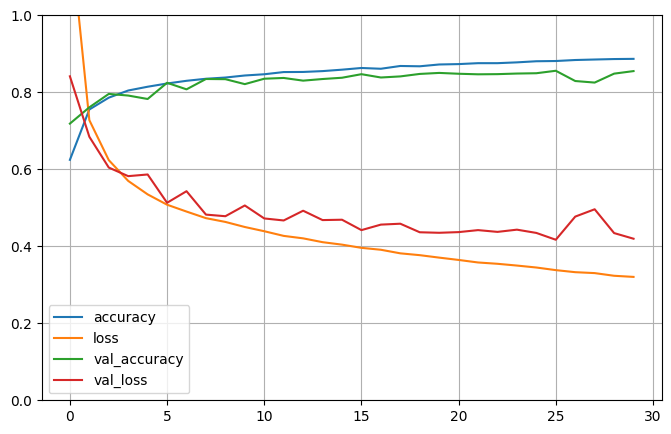

In [32]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [33]:
model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8063 - loss: 92.7472


[92.7471694946289, 0.8062999844551086]

In [34]:
X_new = x_test[:3]
y_proba = model.predict(X_new)
y_proba.round(2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

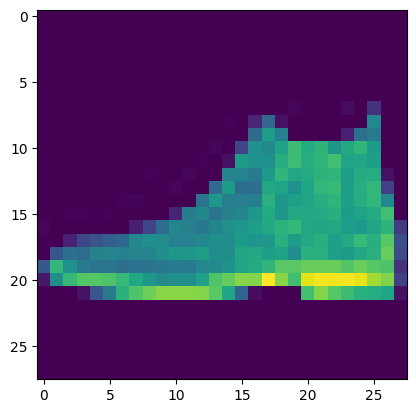

In [35]:
plt.imshow(x_test[0])

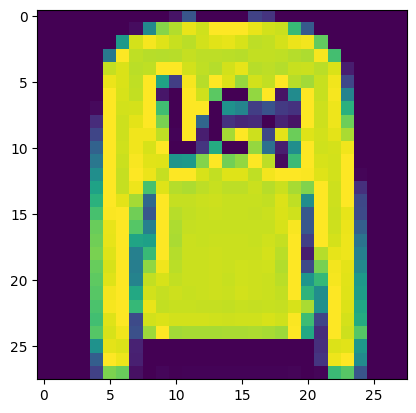

In [36]:
plt.imshow(x_test[1])

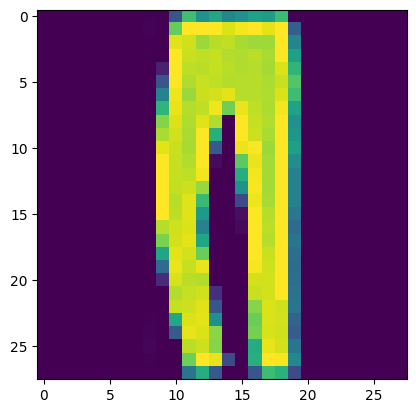

In [37]:
plt.imshow(x_test[2])

In [38]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [39]:
housing = fetch_california_housing()

In [40]:
X_train_full, X_test, y_train_full, y_test = train_test_split(housing.data, housing.target)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full)

In [41]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

In [42]:
X_train.shape[1:]

(8,)

In [43]:
model = keras.models.Sequential([
keras.layers.Dense(30, activation="sigmoid", input_shape=X_train_scaled.shape[1:]),
keras.layers.Dense(1)
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [44]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 30)             │           270 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 301 (1.18 KB)

 Trainable params: 301 (1.18 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
model.compile(loss="mean_squared_error",optimizer="sgd")

In [46]:

history = model.fit(X_train_scaled,y_train, epochs=50,validation_data=(X_valid_scaled,y_valid))

Epoch 1/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.9620 - val_loss: 0.6442
Epoch 2/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6123 - val_loss: 0.5832
Epoch 3/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5704 - val_loss: 0.5492
Epoch 4/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5444 - val_loss: 0.5253
Epoch 5/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5250 - val_loss: 0.5101
Epoch 6/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5110 - val_loss: 0.4947
Epoch 7/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5012 - val_loss: 0.4908
Epoch 8/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4938 - val_loss: 0.4832
Epoch 9/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4896 - val_loss: 0.4761
Epoch 10/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4864 - val_loss: 0.4728
Epoch 11/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4830 - val_loss: 0.4691
Epoch 12/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/ste

In [47]:
mse_test = model.evaluate(X_test_scaled, y_test)

162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4254


In [48]:
X_new = X_test_scaled[:3]

In [49]:
y_pred = model.predict(X_new)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


In [50]:
y_pred

array([[2.1384792],
       [1.7586268],
       [2.9460156]], dtype=float32)

In [51]:
input = keras.layers.Input(shape=X_train.shape[1:])
hidden1 = keras.layers.Dense(30, activation="relu")(input)
hidden2 = keras.layers.Dense(30, activation="relu")(hidden1)
concat = keras.layers.Concatenate()([input, hidden2])
output = keras.layers.Dense(1)(concat)
model = keras.models.Model(inputs=[input], outputs=[output])

In [52]:
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 30)        │        270 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 30)        │        930 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 38)        │          0 │ input_layer_2[0]… │
│ (Concatenate)       │                   │            │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │         39 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,239 (4.84 KB)

 Trainable params: 1,239 (4.84 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
model.compile(loss="mean_squared_error",optimizer="sgd")

In [54]:
history = model.fit(X_train_scaled,y_train, epochs=50,validation_data=(X_valid_scaled,y_valid))

Epoch 1/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.7106 - val_loss: 1.1391
Epoch 2/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 2.0769 - val_loss: 20.8490
Epoch 3/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 57.7920 - val_loss: 592.0962
Epoch 4/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: nan - val_loss: nan
Epoch 5/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: nan - val_loss: nan
Epoch 6/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: nan - val_loss: nan
Epoch 7/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: nan - val_loss: nan
Epoch 8/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: nan - val_loss: nan
Epoch 9/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: nan - val_loss: nan
Epoch 10/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: nan - val_loss: nan
Epoch 11/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: nan - val_loss: nan
Epoch 12/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: nan - val_loss: nan
Epoch 13/50
363

In [55]:
mse_test = model.evaluate(X_test_scaled, y_test)

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: nan


In [56]:
X_new = X_test_scaled[:3]
y_pred=model.predict(X_new)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


array([[nan],
       [nan],
       [nan]], dtype=float32)